# 9. Modelo base: línea base trivial y regresión logística

**Qué hacemos** (ruta A del enunciado):

- **Línea base:** `DummyClassifier` (siempre responde la clase mayoritaria) y **regresión logística** dentro del Pipeline del capítulo 8.
- **Métricas:** accuracy, precision, recall, F1, AUC, Average Precision, matriz de confusión, curvas ROC y PR, calibración.
- **Incertidumbre:** intervalos bootstrap que remuestrean **pacientes**, y diferencia frente a la línea base con los mismos pacientes.
- **Diagnóstico:** curva de aprendizaje, interpretación de coeficientes (odds ratios) y desempeño por subgrupos.
- **Auditoría** del criterio «accuracy ≥ 80–90 %» del enunciado.

La validación cruzada usa solo el entrenamiento (5 pliegues agrupados por paciente); la **prueba se usa una sola vez**, al final.

In [1]:
from pathlib import Path
import re, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

project_root = Path.cwd().resolve()
while not (project_root / "_config.yml").exists():
    if project_root.parent == project_root:
        raise FileNotFoundError("No se encontró _config.yml. Ejecuta el notebook dentro de la carpeta del libro.")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

for _folder in ("tables", "figures"):          # se crean si no existen
    (project_root / _folder).mkdir(exist_ok=True)

from src.project_utils import *

configure_plots()
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 70)
TABLES = project_root / "tables"

def md_out(text):
    display(Markdown(text))

# El OneHotEncoder usa handle_unknown="infrequent_if_exist": una categoría que aparece en validación/prueba y no en el ajuste
# se codifica como ceros (comportamiento deseado y documentado). Se silencia solo ese aviso, también en los procesos de joblib.
import os
_msg_onehot = "Found unknown categories"
warnings.filterwarnings("ignore", message=_msg_onehot, category=UserWarning)
os.environ["PYTHONWARNINGS"] = ",".join(filter(None, [os.environ.get("PYTHONWARNINGS", ""), f"ignore:{_msg_onehot}:UserWarning"]))

from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay, brier_score_loss, f1_score,
                             make_scorer, precision_recall_curve, precision_score, recall_score, roc_curve)
from sklearn.model_selection import cross_val_predict, cross_validate, learning_curve

pop = pd.read_csv(TABLES / "decision_poblacion.csv").iloc[0]
excluir = bool(pop["excluir_terminales"])
dec = pd.read_csv(TABLES / "decision_transformacion.csv").iloc[0]
cm = pd.read_csv(TABLES / "columnas_modelo.csv")
num_lin, num_log, cat = [cm.loc[cm["grupo"] == g, "variable"].tolist() for g in ("num_lin", "num_log", "cat")]
todas = num_lin + num_log + cat

train, test = load_train(include_terminal=not excluir), load_test(include_terminal=not excluir)
Ftr, Fte = prepare_frame(train), prepare_frame(test)
Xtr, ytr, gtr = Ftr[todas], Ftr[TARGET], Ftr[GROUP_COL]
Xte, yte, gte = Fte[todas], Fte[TARGET], Fte[GROUP_COL]
folds = cv_folds(ytr, gtr)
def nuevo_modelo():
    return make_model_pipeline(num_lin, num_log, cat)

In [2]:
md_out(f"- **Entrenamiento:** {es(len(train), 0)} encuentros de {es(gtr.nunique(), 0)} pacientes; reingreso <30 {es(ytr.mean(), 1, pct=True)}\n"
       f"- **Prueba:** {es(len(test), 0)} encuentros de {es(gte.nunique(), 0)} pacientes; reingreso <30 {es(yte.mean(), 1, pct=True)}\n"
       f"- **Variables del modelo:** {len(todas)} ({len(num_lin) + len(num_log)} numéricas, {len(cat)} categóricas); "
       f"`log1p` en los conteos: {'sí' if bool(dec['usar_log1p']) else 'no'} (decisión del capítulo 8)")

- **Entrenamiento:** 79.473 encuentros de 55.990 pacientes; reingreso <30 11,3 %
- **Prueba:** 19.870 encuentros de 14.000 pacientes; reingreso <30 11,7 %
- **Variables del modelo:** 44 (9 numéricas, 35 categóricas); `log1p` en los conteos: sí (decisión del capítulo 8)

## 1. Validación cruzada en entrenamiento

Cinco pliegues estratificados y agrupados por paciente. Se reporta media ± desviación entre pliegues. El Dummy no aprende nada:
sirve para mostrar por qué un accuracy alto puede coexistir con recall 0 para la clase `<30`.

In [3]:
scoring = {"accuracy": "accuracy", "precision": make_scorer(precision_score, zero_division=0),
           "recall": make_scorer(recall_score, zero_division=0), "f1": make_scorer(f1_score, zero_division=0),
           "roc_auc": "roc_auc", "average_precision": "average_precision"}
modelos = {"Dummy (clase mayoritaria)": DummyClassifier(strategy="most_frequent"), "Regresión logística": nuevo_modelo()}
filas = []
for nombre, m in modelos.items():
    r = cross_validate(m, Xtr, ytr, cv=folds, scoring=scoring, n_jobs=2, error_score="raise")
    for k in scoring:
        filas.append({"modelo": nombre, "métrica": k, "media": r[f"test_{k}"].mean(), "desv_est": r[f"test_{k}"].std()})
cv_res = pd.DataFrame(filas)
cv_res.to_csv(TABLES / "cv_resumen.csv", index=False)
tabla_cv = cv_res.pivot(index="métrica", columns="modelo", values="media").loc[list(scoring)]
tabla_sd = cv_res.pivot(index="métrica", columns="modelo", values="desv_est").loc[list(scoring)]
display(tabla_cv.round(4).astype(str) + " ± " + tabla_sd.round(4).astype(str))
lr_cv, d_cv = tabla_cv["Regresión logística"], tabla_cv["Dummy (clase mayoritaria)"]
md_out(f"En validación cruzada la regresión logística obtiene un AUC de **{es(lr_cv['roc_auc'], 3)}** frente a 0,5 del Dummy, y un accuracy de "
       f"**{es(lr_cv['accuracy'], 3)}** frente a {es(d_cv['accuracy'], 3)}. La mejora de accuracy es de **{es(100 * (lr_cv['accuracy'] - d_cv['accuracy']), 1)} puntos porcentuales**, pero la comparación principal debe considerar recall, F1 y Average Precision por el desbalance.")

modelo,Dummy (clase mayoritaria),Regresión logística
métrica,,
accuracy,0.8869 ± 0.002,0.8866 ± 0.002
precision,0.0 ± 0.0,0.3962 ± 0.0743
recall,0.0 ± 0.0,0.0051 ± 0.0017
f1,0.0 ± 0.0,0.01 ± 0.0033
roc_auc,0.5 ± 0.0,0.6626 ± 0.0053
average_precision,0.1131 ± 0.002,0.2077 ± 0.0062


En validación cruzada la regresión logística obtiene un AUC de **0,663** frente a 0,5 del Dummy, y un accuracy de **0,887** frente a 0,887. La mejora de accuracy es de **-0,0 puntos porcentuales**, pero la comparación principal debe considerar recall, F1 y Average Precision por el desbalance.

## 2. Ajuste final y evaluación en la prueba

Los dos modelos se ajustan con todo el entrenamiento y se evalúan **una sola vez** en la prueba, con umbral 0,5.

In [4]:
dummy = DummyClassifier(strategy="most_frequent").fit(Xtr, ytr)
lr = nuevo_modelo().fit(Xtr, ytr)
p_dummy, p_lr = dummy.predict_proba(Xte)[:, 1], lr.predict_proba(Xte)[:, 1]
pred_dummy, pred_lr = dummy.predict(Xte), (p_lr >= 0.5).astype(int)

res = pd.DataFrame({"Dummy (clase mayoritaria)": classification_metrics(yte, pred_dummy, p_dummy),
                    "Regresión logística": classification_metrics(yte, pred_lr, p_lr)}).T
res["Brier"] = [brier_score_loss(yte, p_dummy), brier_score_loss(yte, p_lr)]
res.to_csv(TABLES / "resultados_holdout.csv")
display(res.round(4))
md_out(f"En la prueba: accuracy **{es(res.loc['Regresión logística', 'Accuracy'], 3)}** (Dummy {es(res.loc['Dummy (clase mayoritaria)', 'Accuracy'], 3)}), "
       f"AUC **{es(res.loc['Regresión logística', 'ROC-AUC'], 3)}**, recall {es(res.loc['Regresión logística', 'Recall'], 3)}, "
       f"precision {es(res.loc['Regresión logística', 'Precision'], 3)}, F1 {es(res.loc['Regresión logística', 'F1'], 3)}.")

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision,Brier
Dummy (clase mayoritaria),0.8830,0.0000,0.0000,0.0000,0.5000,0.1170,0.1170
Regresión logística,0.8829,0.4167,0.0022,0.0043,0.6575,0.2122,0.0994


En la prueba: accuracy **0,883** (Dummy 0,883), AUC **0,658**, recall 0,002, precision 0,417, F1 0,004.

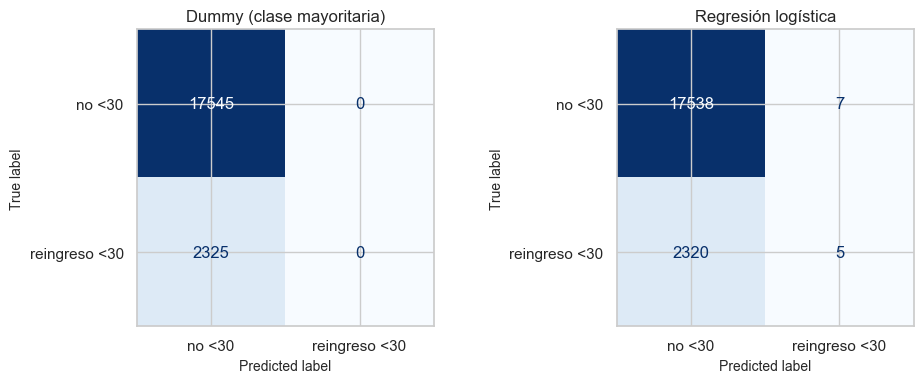

TN=17.538, FP=7, FN=2.320 y TP=5. Un **falso negativo** es un encuentro que sí terminó en reingreso antes de 30 días pero fue clasificado como clase 0; si el modelo se usara para priorización, ese caso podría no recibir seguimiento reforzado. Esta es una interpretación operativa, no una afirmación causal o médica individual.

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, nombre, pred in zip(axes, ["Dummy (clase mayoritaria)", "Regresión logística"], [pred_dummy, pred_lr]):
    ConfusionMatrixDisplay.from_predictions(yte, pred, ax=ax, display_labels=["no <30", "reingreso <30"], colorbar=False, cmap="Blues")
    ax.set_title(nombre)
plt.tight_layout(); save_figure(fig, "09_matrices_confusion.png"); plt.show()
tn, fp, fn, tp = skm.confusion_matrix(yte, pred_lr).ravel()
md_out(f"TN={es(tn, 0)}, FP={es(fp, 0)}, FN={es(fn, 0)} y TP={es(tp, 0)}. Un **falso negativo** es un encuentro que sí terminó en reingreso antes de 30 días pero fue clasificado como clase 0; si el modelo se usara para priorización, ese caso podría no recibir seguimiento reforzado. Esta es una interpretación operativa, no una afirmación causal o médica individual.")

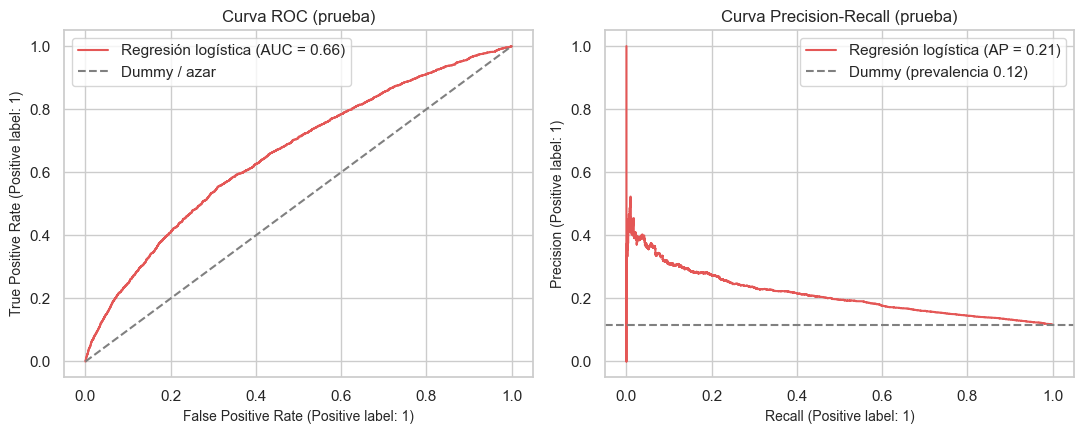

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
RocCurveDisplay.from_predictions(yte, p_lr, name="Regresión logística", ax=axes[0], color="#e45756")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Dummy / azar"); axes[0].legend(); axes[0].set_title("Curva ROC (prueba)")
PrecisionRecallDisplay.from_predictions(yte, p_lr, name="Regresión logística", ax=axes[1], color="#e45756")
axes[1].axhline(yte.mean(), ls="--", color="gray", label=f"Dummy (prevalencia {yte.mean():.2f})"); axes[1].legend(); axes[1].set_title("Curva Precision-Recall (prueba)")
plt.tight_layout(); save_figure(fig, "09_curvas_roc_pr.png"); plt.show()

## 3. Calibración

Una probabilidad está **calibrada** si, entre los pacientes a los que el modelo les asigna 30 %, reingresa cerca del 30 %. Se revisa en la prueba y,
con predicciones **fuera de pliegue**, en el entrenamiento. El **Brier** mide el error cuadrático de las probabilidades (menor es mejor); se compara
con el de predecir siempre la prevalencia.

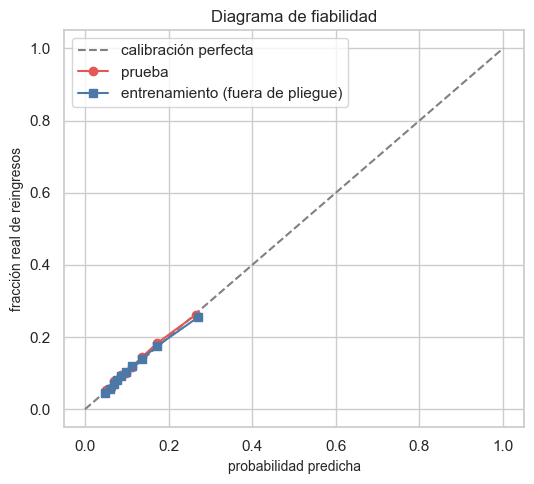

Brier de la regresión logística: **0,0994**; de predecir siempre la prevalencia: 0,1033. La desviación media entre lo predicho y lo observado por tramos es de 0,6 puntos porcentuales: las probabilidades están **bien calibradas** (sin ajuste adicional).

In [7]:
oof = cross_val_predict(nuevo_modelo(), Xtr, ytr, cv=folds, method="predict_proba", n_jobs=2)[:, 1]
f_te, m_te = calibration_curve(yte, p_lr, n_bins=10, strategy="quantile")
f_oof, m_oof = calibration_curve(ytr, oof, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], "--", color="gray", label="calibración perfecta")
ax.plot(m_te, f_te, "o-", color="#e45756", label="prueba"); ax.plot(m_oof, f_oof, "s-", color="#4c78a8", label="entrenamiento (fuera de pliegue)")
ax.set_xlabel("probabilidad predicha"); ax.set_ylabel("fracción real de reingresos"); ax.legend(); ax.set_title("Diagrama de fiabilidad")
plt.tight_layout(); save_figure(fig, "09_calibracion.png"); plt.show()
brier_lr, brier_ref = brier_score_loss(yte, p_lr), brier_score_loss(yte, np.full(len(yte), ytr.mean()))
desv = float(np.mean(np.abs(f_te - m_te)))
md_out(f"Brier de la regresión logística: **{es(brier_lr, 4)}**; de predecir siempre la prevalencia: {es(brier_ref, 4)}. "
       f"La desviación media entre lo predicho y lo observado por tramos es de {es(100 * desv, 1)} puntos porcentuales: "
       + ("las probabilidades están **bien calibradas** (sin ajuste adicional)." if desv < 0.03 else "hay descalibración apreciable; convendría recalibrar antes de usar las probabilidades."))

## 4. Umbral de decisión

El umbral 0,5 no es sagrado. Se elige un **umbral alternativo usando solo las predicciones fuera de pliegue del entrenamiento** (el que maximiza el índice de
Youden: recall − tasa de falsos positivos) y se evalúa en la prueba. Un umbral más bajo detecta más reingresos a costa de más falsas alarmas.

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision,Balanced accuracy
"umbral 0,5",0.8829,0.4167,0.0022,0.0043,0.6575,0.2122,0.5009
"umbral 0.105 (Youden, entrenamiento)",0.6284,0.1775,0.5987,0.2738,0.6575,0.2122,0.6155


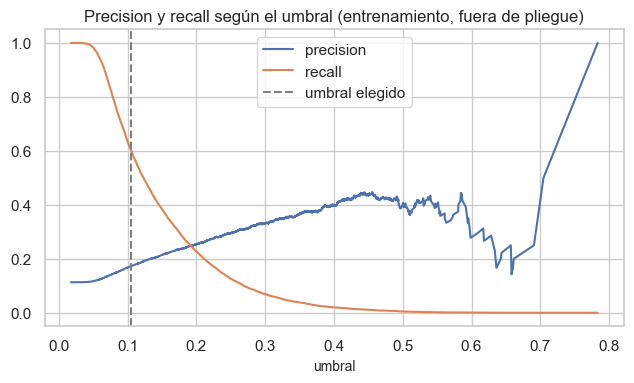

In [8]:
fpr, tpr, thr = roc_curve(ytr, oof)
umbral = float(thr[np.argmax(tpr - fpr)])
def a_umbral(p, u):
    pred = (p >= u).astype(int)
    fila = classification_metrics(yte, pred, p)
    fila["Balanced accuracy"] = skm.balanced_accuracy_score(yte, pred)
    return fila
comp_u = pd.DataFrame({"umbral 0,5": a_umbral(p_lr, 0.5), f"umbral {umbral:.3f} (Youden, entrenamiento)": a_umbral(p_lr, umbral)}).T
comp_u.to_csv(TABLES / "umbral_alternativo.csv")
display(comp_u.round(4))
prec, rec, th = precision_recall_curve(ytr, oof)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(th, prec[:-1], label="precision"); ax.plot(th, rec[:-1], label="recall"); ax.axvline(umbral, color="gray", ls="--", label="umbral elegido")
ax.set_xlabel("umbral"); ax.legend(); ax.set_title("Precision y recall según el umbral (entrenamiento, fuera de pliegue)")
plt.tight_layout(); save_figure(fig, "09_umbral.png"); plt.show()

## 5. Intervalos de confianza: bootstrap por paciente

Como un paciente tiene varios encuentros, remuestrear **filas** subestimaría la incertidumbre. Se remuestrean **pacientes completos** (1.000 réplicas) y se
calcula el intervalo percentil del 95 %. Para comparar con el Dummy se usan **los mismos pacientes remuestreados** en ambos modelos.

In [9]:
ic = cluster_bootstrap(yte, pred_lr, p_lr, gte, B=1000)
ic_d = cluster_bootstrap(yte, pred_dummy, p_dummy, gte, B=1000)
dif = paired_cluster_bootstrap(yte, pred_lr, p_lr, pred_dummy, p_dummy, gte, B=1000)
ic.to_csv(TABLES / "intervalos_bootstrap_logistica.csv")
dif.to_csv(TABLES / "diferencias_vs_dummy.csv")
display(ic.round(4)); display(dif.round(4))

comprobacion_ic = pd.DataFrame({
    "métrica": dif.index,
    "diferencia_logistica_menos_dummy": dif["Diferencia"].values,
    "ic_inferior": dif["IC inferior"].values,
    "ic_superior": dif["IC superior"].values,
    "ic_excluye_cero": ((dif["IC inferior"] > 0) | (dif["IC superior"] < 0)).values,
})
comprobacion_ic.to_csv(TABLES / "comprobacion_ic_por_metrica.csv", index=False)
display(comprobacion_ic.round(4))
for metric in ["Accuracy", "Recall", "F1", "ROC-AUC", "Average Precision"]:
    row = dif.loc[metric]
    conclusion = "excluye cero" if (row["IC inferior"] > 0 or row["IC superior"] < 0) else "incluye cero"
    md_out(f"- **{metric}:** diferencia {es(row['Diferencia'], 3)}, IC 95 % {es(row['IC inferior'], 3)} a {es(row['IC superior'], 3)}; el intervalo **{conclusion}**.")
n_pos_pred = int(tp + fp)
md_out(f"- **Precisión con umbral 0,5:** el valor {es(ic.loc['Precision', 'Estimación'], 3)} se apoya en solo **{n_pos_pred} predicciones positivas** "
       f"({tp} aciertos) entre {es(len(yte), 0)} encuentros de prueba; su IC bootstrap va de {es(ic.loc['Precision', 'IC 95 % inferior'], 2)} "
       f"a {es(ic.loc['Precision', 'IC 95 % superior'], 2)}. **No debe interpretarse como un desempeño estable** del modelo.")

,Estimación,IC 95 % inferior,IC 95 % superior
Métrica,,,
Accuracy,0.8829,0.8779,0.8879
Precision,0.4167,0.1429,0.7500
Recall,0.0022,0.0004,0.0043
F1,0.0043,0.0009,0.0085
ROC-AUC,0.6575,0.6451,0.6711
Average Precision,0.2122,0.1977,0.2306


,Diferencia,IC inferior,IC superior
Métrica,,,
Accuracy,-0.0001,-0.0005,0.0003
Precision,0.4167,0.1429,0.7500
Recall,0.0022,0.0004,0.0043
F1,0.0043,0.0009,0.0085
ROC-AUC,0.1575,0.1451,0.1711
Average Precision,0.0952,0.0832,0.1106


,métrica,diferencia_logistica_menos_dummy,ic_inferior,ic_superior,ic_excluye_cero
0,Accuracy,-0.0001,-0.0005,0.0003,False
1,Precision,0.4167,0.1429,0.7500,True
2,Recall,0.0022,0.0004,0.0043,True
3,F1,0.0043,0.0009,0.0085,True
4,ROC-AUC,0.1575,0.1451,0.1711,True
5,Average Precision,0.0952,0.0832,0.1106,True


- **Accuracy:** diferencia -0,000, IC 95 % -0,000 a 0,000; el intervalo **incluye cero**.

- **Recall:** diferencia 0,002, IC 95 % 0,000 a 0,004; el intervalo **excluye cero**.

- **F1:** diferencia 0,004, IC 95 % 0,001 a 0,008; el intervalo **excluye cero**.

- **ROC-AUC:** diferencia 0,158, IC 95 % 0,145 a 0,171; el intervalo **excluye cero**.

- **Average Precision:** diferencia 0,095, IC 95 % 0,083 a 0,111; el intervalo **excluye cero**.

- **Precisión con umbral 0,5:** el valor 0,417 se apoya en solo **12 predicciones positivas** (5 aciertos) entre 19.870 encuentros de prueba; su IC bootstrap va de 0,14 a 0,75. **No debe interpretarse como un desempeño estable** del modelo.

## 6. Curva de aprendizaje

Se utiliza **Average Precision**, más informativa que accuracy bajo desbalance.
Los folds de validación respetan `patient_nbr`; ningún paciente de validación
aparece en el entrenamiento del mismo fold.

,n_train,ap_entrenamiento_media,ap_entrenamiento_desv,ap_validacion_media,ap_validacion_desv
0,6352,0.2286,0.0051,0.1801,0.0096
1,15882,0.2321,0.0047,0.1965,0.0049
2,31764,0.2294,0.0040,0.2036,0.0065
3,47646,0.2157,0.0020,0.2064,0.0060
4,63529,0.2135,0.0014,0.2077,0.0062


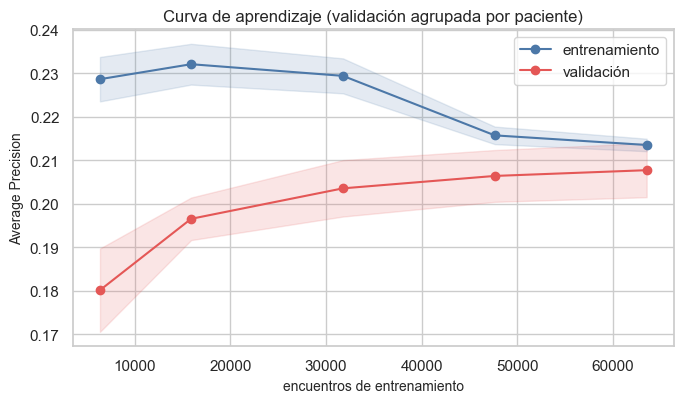

Con todos los datos, el Average Precision es 0,214 en entrenamiento y 0,208 en validación (brecha 0,006). Pasar de 75 % a 100 % de los datos cambia el Average Precision de validación en 0,0013. La curva **se aplana**: más datos con este mismo modelo aportarían poco; la mejora vendría de mejores variables o de un modelo más flexible.

In [10]:
tam, tr_s, va_s = learning_curve(
    nuevo_modelo(), Xtr, ytr, cv=folds,
    train_sizes=[0.1, 0.25, 0.5, 0.75, 1.0],
    scoring="average_precision", n_jobs=2,
)
curva_aprendizaje = pd.DataFrame({
    "n_train": tam,
    "ap_entrenamiento_media": tr_s.mean(axis=1),
    "ap_entrenamiento_desv": tr_s.std(axis=1),
    "ap_validacion_media": va_s.mean(axis=1),
    "ap_validacion_desv": va_s.std(axis=1),
})
curva_aprendizaje.to_csv(TABLES / "curva_aprendizaje.csv", index=False)
display(curva_aprendizaje.round(4))

fig, ax = plt.subplots(figsize=(7, 4.2))
for s, nombre, c in [(tr_s, "entrenamiento", "#4c78a8"), (va_s, "validación", "#e45756")]:
    ax.plot(tam, s.mean(axis=1), "o-", color=c, label=nombre)
    ax.fill_between(tam, s.mean(axis=1) - s.std(axis=1), s.mean(axis=1) + s.std(axis=1), color=c, alpha=0.15)
ax.set_xlabel("encuentros de entrenamiento"); ax.set_ylabel("Average Precision")
ax.legend(); ax.set_title("Curva de aprendizaje (validación agrupada por paciente)")
plt.tight_layout(); save_figure(fig, "09_curva_aprendizaje.png"); plt.show()
brecha = tr_s.mean(axis=1)[-1] - va_s.mean(axis=1)[-1]
ultimo = va_s.mean(axis=1)[-1] - va_s.mean(axis=1)[-2]
md_out(f"Con todos los datos, el Average Precision es {es(tr_s.mean(axis=1)[-1], 3)} en entrenamiento y {es(va_s.mean(axis=1)[-1], 3)} en validación (brecha {es(brecha, 3)}). "
       f"Pasar de 75 % a 100 % de los datos cambia el Average Precision de validación en {es(ultimo, 4)}. "
       + ("La curva **se aplana**: más datos con este mismo modelo aportarían poco; la mejora vendría de mejores variables o de un modelo más flexible." if ultimo < 0.003 else
          "La curva sigue subiendo: más datos podrían ayudar."))

## 7. Interpretación de coeficientes y odds ratios

Las numéricas se interpretan por una desviación estándar. En las categóricas,
`OneHotEncoder(drop='first')` elimina una categoría por variable: cada odds
ratio compara el nivel indicado con esa referencia, manteniendo las demás
variables constantes. Los resultados son asociaciones ajustadas, no efectos
causales.

,variable,coeficiente,odds_ratio,tipo
0,cat__discharge_disposition_id_22,1.286,3.620,indicador de categoría
1,cat__discharge_disposition_id_5,0.889,2.432,indicador de categoría
2,cat__tolazamide_infrequent_sklearn,-0.606,0.545,indicador de categoría
3,cat__discharge_disposition_id_2,0.543,1.721,indicador de categoría
4,cat__medical_specialty_Nephrology,0.535,1.707,indicador de categoría
5,cat__tolbutamide_infrequent_sklearn,-0.458,0.633,indicador de categoría
6,cat__chlorpropamide_infrequent_sklearn,-0.420,0.657,indicador de categoría
7,cat__diag_2_grupo_Neoplasias,0.402,1.495,indicador de categoría
8,cat__discharge_disposition_id_infrequent_sklearn,0.369,1.447,indicador de categoría
9,numlog__number_inpatient,0.369,1.447,numérica estandarizada


,variable,categoría_referencia
0,race,AfricanAmerican
1,gender,Female
2,admission_type_id,1
3,discharge_disposition_id,1
4,admission_source_id,1
5,payer_code,BC
6,medical_specialty,Cardiology
7,max_glu_serum,>200
8,A1Cresult,>7
9,metformin,No


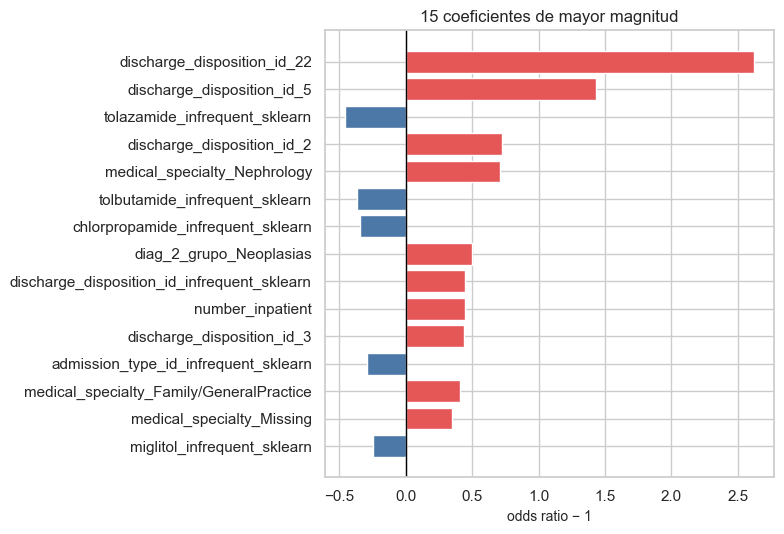

La variable transformada con mayor asociación positiva es `cat__discharge_disposition_id_22` (OR 3,62) y la de mayor asociación negativa es `cat__tolazamide_infrequent_sklearn` (OR 0,55). La interpretación exacta de variables categóricas debe consultar su referencia en la tabla anterior. No se atribuye causalidad.

In [11]:
orr = odds_ratio_table(lr)
referencias = onehot_reference_table(lr, cat)
orr.to_csv(TABLES / "odds_ratios.csv", index=False)
referencias.to_csv(TABLES / "categorias_referencia_onehot_final.csv", index=False)
display(orr.head(15).round(3)); display(referencias.head(12))
t = orr.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(t["variable"].str.replace("cat__", "").str.replace("numlog__", "").str.replace("num__", ""), t["odds_ratio"] - 1,
        color=np.where(t["odds_ratio"] > 1, "#e45756", "#4c78a8"))
ax.axvline(0, color="black", lw=1); ax.set_xlabel("odds ratio − 1")
ax.set_title("15 coeficientes de mayor magnitud"); plt.tight_layout(); save_figure(fig, "09_odds_ratios.png"); plt.show()
sube, baja = orr[orr["odds_ratio"] > 1].iloc[0], orr[orr["odds_ratio"] < 1].iloc[0]
md_out(f"La variable transformada con mayor asociación positiva es `{sube['variable']}` (OR {es(sube['odds_ratio'], 2)}) y la de mayor asociación negativa es `{baja['variable']}` (OR {es(baja['odds_ratio'], 2)}). La interpretación exacta de variables categóricas debe consultar su referencia en la tabla anterior. No se atribuye causalidad.")

## 8. Desempeño por subgrupos

Por razones éticas se revisa si el modelo rinde de forma parecida en subgrupos de sexo, raza y edad (solo grupos con al menos 300 encuentros de prueba y
ambas clases). Diferencias grandes indicarían que el modelo puede perjudicar más a un grupo.

In [12]:
Fte = Fte.assign(grupo_edad=pd.cut(Fte["age_mid"], [0, 50, 70, 200], right=False, labels=["<50", "50–69", "70+"]).astype("object"))
def por_grupo(col, min_n=300, u=0.5):
    s = Fte[col].astype("object").where(Fte[col].notna(), "Missing")
    filas = []
    for val in s.unique():
        m = (s == val).to_numpy()
        if m.sum() < min_n or yte[m].nunique() < 2:
            continue
        pr = (p_lr[m] >= u).astype(int)
        filas.append({col: val, "encuentros": int(m.sum()), "reingreso_%": 100 * yte[m].mean(), "AUC": skm.roc_auc_score(yte[m], p_lr[m]),
                      "recall": skm.recall_score(yte[m], pr, zero_division=0), "precision": skm.precision_score(yte[m], pr, zero_division=0),
                      "accuracy": skm.accuracy_score(yte[m], pr)})
    return pd.DataFrame(filas).sort_values("encuentros", ascending=False)
sub = {c: por_grupo(c) for c in ["gender", "race", "grupo_edad"]}
todos = pd.concat([d.rename(columns={c: "grupo"}).assign(variable=c) for c, d in sub.items()])
todos.to_csv(TABLES / "desempeno_subgrupos.csv", index=False)
for c, d in sub.items():
    display(d.round(3))
rango = todos["AUC"].max() - todos["AUC"].min()
md_out(f"El AUC por subgrupo va de **{es(todos['AUC'].min(), 3)}** a **{es(todos['AUC'].max(), 3)}** (rango {es(rango, 3)}). "
       + ("El rendimiento es **parecido** entre subgrupos." if rango < 0.05 else "Hay diferencias entre subgrupos que deben vigilarse antes de cualquier uso."))

,gender,encuentros,reingreso_%,AUC,recall,precision,accuracy
1,Female,10795,11.672,0.661,0.002,0.429,0.883
0,Male,9074,11.737,0.653,0.002,0.400,0.883


,race,encuentros,reingreso_%,AUC,recall,precision,accuracy
0,Caucasian,14655,11.682,0.659,0.002,0.375,0.883
1,AfricanAmerican,3884,12.461,0.645,0.004,0.500,0.875
2,Missing,469,10.021,0.654,0.000,0.000,0.900
4,Hispanic,422,10.427,0.736,0.000,0.000,0.896
3,Other,320,9.062,0.685,0.000,0.000,0.909


,grupo_edad,encuentros,reingreso_%,AUC,recall,precision,accuracy
2,70+,8885,12.549,0.647,0.002,0.400,0.874
1,50–69,7780,10.784,0.650,0.002,0.500,0.892
0,<50,3205,11.576,0.695,0.003,0.333,0.884


El AUC por subgrupo va de **0,645** a **0,736** (rango 0,091). Hay diferencias entre subgrupos que deben vigilarse antes de cualquier uso.

### Subgrupos con el umbral alternativo

Con el umbral 0,5 el modelo casi no predice positivos (recall global muy cercano a 0), así que el recall y la precisión por subgrupo no permiten comparar grupos. Se repite la tabla con el **umbral de Youden elegido en la sección 4 con las predicciones fuera de pliegue del entrenamiento** (no se recalcula con la prueba); los mismos criterios de inclusión: al menos 300 encuentros y ambas clases.

In [13]:
sub_alt = {c: por_grupo(c, u=umbral) for c in ["gender", "race", "grupo_edad"]}
todos_alt = pd.concat([d.rename(columns={c: "grupo"}).assign(variable=c) for c, d in sub_alt.items()])
todos_alt = todos_alt.assign(umbral=umbral)
todos_alt.to_csv(TABLES / "desempeno_subgrupos_umbral_alt.csv", index=False)
md_out(f"Umbral aplicado: **{es(umbral, 3)}** (Youden, entrenamiento fuera de pliegue).")
for c, d in sub_alt.items():
    display(d.round(3))
def extremos(t, met):
    g = t.columns[0]                      # columna con el nombre del grupo (gender, race o grupo_edad)
    t = t.sort_values(met); lo, hi = t.iloc[0], t.iloc[-1]
    return f"de {es(lo[met], 3)} (`{lo[g]}`) a {es(hi[met], 3)} (`{hi[g]}`)"
pred_alt = (p_lr >= umbral).astype(int)
glob_rec, glob_pre = skm.recall_score(yte, pred_alt), skm.precision_score(yte, pred_alt)
lineas = []
for c, d in sub_alt.items():
    lineas.append(f"- **{c}:** recall {extremos(d, 'recall')}; precisión {extremos(d, 'precision')}.")
grandes = todos_alt[todos_alt["encuentros"] >= 1000]
pequenos = todos_alt[todos_alt["encuentros"] < 1000].assign(positivos=lambda d: (d["encuentros"] * d["reingreso_%"] / 100).round())
r_rec, r_pre = grandes["recall"].max() - grandes["recall"].min(), grandes["precision"].max() - grandes["precision"].min()
md_out(f"Con este umbral el recall global es **{es(glob_rec, 3)}** y la precisión global **{es(glob_pre, 3)}** (frente a un recall prácticamente nulo con 0,5).\n\n"
       + "\n".join(lineas) + "\n\n"
       f"En los grupos con al menos 1.000 encuentros, el recall varía {es(r_rec, 3)} y la precisión solo {es(r_pre, 3)}: con un mismo umbral, "
       f"la **precisión es bastante homogénea** (entre {es(100 * todos_alt['precision'].min(), 0)} % y {es(100 * todos_alt['precision'].max(), 0)} % de las alertas son reingresos reales en todos los grupos), mientras que el **recall "
       "difiere más**, es decir, la proporción de reingresos que se detecta no es igual entre grupos. En edad, el grupo de mayor recall recibe también "
       "más alertas (menor accuracy), por lo que su mayor detección se paga con más falsas alarmas. "
       + (f"Los grupos pequeños ({', '.join(f'`{g}`' for g in pequenos['grupo'])}) tienen como máximo {int(pequenos['positivos'].max())} reingresos cada uno y sus cifras son inestables; no deben leerse como diferencias reales. " if len(pequenos) else "")
       + "Estas diferencias deben vigilarse antes de cualquier uso; el umbral se fijó con el entrenamiento y la prueba solo se usa para describirlas.")

Umbral aplicado: **0,105** (Youden, entrenamiento fuera de pliegue).

,gender,encuentros,reingreso_%,AUC,recall,precision,accuracy
1,Female,10795,11.672,0.661,0.612,0.179,0.626
0,Male,9074,11.737,0.653,0.583,0.176,0.631


,race,encuentros,reingreso_%,AUC,recall,precision,accuracy
0,Caucasian,14655,11.682,0.659,0.609,0.176,0.622
1,AfricanAmerican,3884,12.461,0.645,0.570,0.182,0.627
2,Missing,469,10.021,0.654,0.404,0.183,0.759
4,Hispanic,422,10.427,0.736,0.682,0.203,0.687
3,Other,320,9.062,0.685,0.655,0.162,0.662


,grupo_edad,encuentros,reingreso_%,AUC,recall,precision,accuracy
2,70+,8885,12.549,0.647,0.642,0.175,0.574
1,50–69,7780,10.784,0.650,0.555,0.171,0.662
0,<50,3205,11.576,0.695,0.566,0.205,0.696


Con este umbral el recall global es **0,599** y la precisión global **0,178** (frente a un recall prácticamente nulo con 0,5).

- **gender:** recall de 0,583 (`Male`) a 0,612 (`Female`); precisión de 0,176 (`Male`) a 0,179 (`Female`).
- **race:** recall de 0,404 (`Missing`) a 0,682 (`Hispanic`); precisión de 0,162 (`Other`) a 0,203 (`Hispanic`).
- **grupo_edad:** recall de 0,555 (`50–69`) a 0,642 (`70+`); precisión de 0,171 (`50–69`) a 0,205 (`<50`).

En los grupos con al menos 1.000 encuentros, el recall varía 0,087 y la precisión solo 0,034: con un mismo umbral, la **precisión es bastante homogénea** (entre 16 % y 21 % de las alertas son reingresos reales en todos los grupos), mientras que el **recall difiere más**, es decir, la proporción de reingresos que se detecta no es igual entre grupos. En edad, el grupo de mayor recall recibe también más alertas (menor accuracy), por lo que su mayor detección se paga con más falsas alarmas. Los grupos pequeños (`Missing`, `Hispanic`, `Other`) tienen como máximo 47 reingresos cada uno y sus cifras son inestables; no deben leerse como diferencias reales. Estas diferencias deben vigilarse antes de cualquier uso; el umbral se fijó con el entrenamiento y la prueba solo se usa para describirlas.

## 9. Auditoría del criterio «accuracy ≥ 80–90 %»

El diagrama del enunciado pide, si el accuracy (o R²) llega a 80–90 %, **verificar fuga, comparar con la línea base, revisar la complejidad y evaluar si el problema es
trivial**. Se responde con los números de este libro.

In [14]:
acc_lr, acc_d = res.loc["Regresión logística", "Accuracy"], res.loc["Dummy (clase mayoritaria)", "Accuracy"]
auc_lr = res.loc["Regresión logística", "ROC-AUC"]
fuga = pd.read_csv(TABLES / "auditoria_fuga.csv")
# Solo predictoras candidatas: se excluyen el objetivo y su fuente (decision == "Excluir del conjunto X", AUC = 1 por construcción)
# y los identificadores, que nunca entran al modelo.
fuga_x = fuga[(fuga["decision"] != "Excluir del conjunto X") & (~fuga["variable"].isin([ID_COL, GROUP_COL]))]
fila_max = fuga_x.loc[fuga_x["AUC univariado"].idxmax()]
max_uni, var_max = float(fila_max["AUC univariado"]), str(fila_max["variable"])
activa = bool(acc_lr >= 0.80)
audit = pd.DataFrame([
    {"criterio": "Accuracy del modelo en la prueba", "resultado": es(acc_lr, 3), "umbral": "≥ 0,80", "se cumple": acc_lr >= 0.80},
    {"criterio": "Accuracy de la línea base trivial", "resultado": es(acc_d, 3), "umbral": "—", "se cumple": acc_d >= 0.80},
    {"criterio": "Mejora del modelo sobre la línea base (pp)", "resultado": es(100 * (acc_lr - acc_d), 1), "umbral": "—", "se cumple": None},
    {"criterio": "AUC del modelo", "resultado": es(auc_lr, 3), "umbral": "≥ 0,90 sospechoso", "se cumple": auc_lr >= 0.90},
    {"criterio": "Mayor AUC univariado de una predictora candidata (capítulo 7)", "resultado": es(max_uni, 3), "umbral": "> 0,90 alerta de fuga", "se cumple": max_uni > 0.90, "variable": var_max},
    {"criterio": "Variables del modelo tras codificar", "resultado": str(len(lr.named_steps['prep'].get_feature_names_out())), "umbral": "—", "se cumple": None},
])
audit = audit[["criterio", "variable", "resultado", "umbral", "se cumple"]]
audit.to_csv(TABLES / "auditoria_nota_critica.csv", index=False)
display(audit)
md_out("**Lectura de la auditoría:**\n\n"
       f"- **Criterio del diagrama:** el accuracy del modelo es {es(acc_lr, 3)}, "
       + ("**inferior a 0,80: el diagrama conduce directamente al entregable**, sin necesidad de cambiar de dataset." if not activa else
          "**igual o superior a 0,80: se activa la revisión** (fuga, línea base, complejidad).") + "\n"
       f"- **Línea base:** el Dummy obtiene {es(acc_d, 3)}; el modelo mejora {es(100 * (acc_lr - acc_d), 1)} puntos porcentuales.\n"
       f"- **Fuga:** la mayor señal individual entre las predictoras candidatas es {es(max_uni, 3)} (`{var_max}`)"
       + (" (sin variable sospechosa); el objetivo, su fuente `readmitted` y los identificadores se excluyen del cálculo porque no forman parte de X." if max_uni <= 0.90 else " (variable sospechosa: revisar).") + "\n"
       f"- **Complejidad:** un modelo lineal con AUC {es(auc_lr, 3)}"
       + (" no es un problema trivial: hay margen de mejora con modelos más flexibles." if auc_lr < 0.85 else " es alto; conviene comparar con modelos más simples y revisar de nuevo la fuga.") )

,criterio,variable,resultado,umbral,se cumple
0,Accuracy del modelo en la prueba,NaN,"0,883","≥ 0,80",True
1,Accuracy de la línea base trivial,NaN,"0,883",—,True
2,Mejora del modelo sobre la línea base (pp),NaN,"-0,0",—,None
3,AUC del modelo,NaN,"0,658","≥ 0,90 sospechoso",False
4,Mayor AUC univariado de una predictora candidata (capítulo 7),number_inpatient,"0,610","> 0,90 alerta de fuga",False
5,Variables del modelo tras codificar,NaN,120,—,None


**Lectura de la auditoría:**

- **Criterio del diagrama:** el accuracy del modelo es 0,883, **igual o superior a 0,80: se activa la revisión** (fuga, línea base, complejidad).
- **Línea base:** el Dummy obtiene 0,883; el modelo mejora -0,0 puntos porcentuales.
- **Fuga:** la mayor señal individual entre las predictoras candidatas es 0,610 (`number_inpatient`) (sin variable sospechosa); el objetivo, su fuente `readmitted` y los identificadores se excluyen del cálculo porque no forman parte de X.
- **Complejidad:** un modelo lineal con AUC 0,658 no es un problema trivial: hay margen de mejora con modelos más flexibles.

In [15]:
# =====================================================================================================
# Revisión que pide el diagrama del enunciado cuando accuracy o R² ≥ 80–90 %:
# verificar fuga, comparar con la línea base y revisar la complejidad; corregir y repetir,
# o considerar un dataset más desafiante.
# Las decisiones se toman SOLO con el entrenamiento (validación cruzada agrupada por paciente);
# la prueba únicamente se reporta como referencia.
# =====================================================================================================
from scipy import sparse
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

UMBRAL_ACCURACY = 0.80    # el diagrama se activa con accuracy ≥ 0,80
UMBRAL_FUGA = 0.90        # AUC univariado por encima del cual una predictora es sospechosa (sección 2.5)
UMBRAL_TRIVIAL = 0.90     # AUC de la regresión logística (CV) por encima del cual el problema es demasiado fácil
MARGEN_ACC_PP = 1.0       # mejora mínima de accuracy sobre la línea base, en puntos porcentuales
MARGEN_AUC = 0.01         # mejora mínima de AUC para hablar de señal no lineal sin explotar
TOL_PERMUTACION = 0.02    # con etiquetas barajadas el AUC debe quedar a menos de 0,02 de 0,5
MAX_RONDAS = 3
PERMUTAR_ETIQUETAS = True                        # prueba de control contra fuga en el Pipeline
REVISAR_COMPLEJIDAD_CON_MODELO_FLEXIBLE = True   # diagnóstico adicional, solo con validación cruzada

esquema = {"num_lin": list(num_lin), "num_log": list(num_log), "cat": list(cat)}


def columnas_de(e):
    return e["num_lin"] + e["num_log"] + e["cat"]


def pipeline_de(e):
    return make_model_pipeline(e["num_lin"], e["num_log"], e["cat"])


def auc_univariado_train(e):
    """AUC de cada predictora por sí sola, con el entrenamiento (categóricas: tasa del objetivo fuera de pliegue)."""
    filas = []
    for grupo, tipo in (("num_lin", "numérica"), ("num_log", "numérica"), ("cat", "categórica")):
        for c in e[grupo]:
            a = univariate_auc(Ftr[c], ytr) if tipo == "numérica" else categorical_auc_oof(Ftr[c], ytr, gtr)
            filas.append({"variable": c, "tipo": tipo, "AUC univariado": a})
    return pd.DataFrame(filas).sort_values("AUC univariado", ascending=False).reset_index(drop=True)


# ---------------------------------------------------------------------------------------------------
# 1) Verificar fuga y, si aparece, corregir (excluir la variable) y repetir
# ---------------------------------------------------------------------------------------------------
scoring_rev = {"accuracy": "accuracy", "roc_auc": "roc_auc", "average_precision": "average_precision"}
rondas, quitadas, sin_resolver = [], [], False
for ronda in range(1, MAX_RONDAS + 1):
    cols = columnas_de(esquema)
    uni = auc_univariado_train(esquema)
    sospechosas = uni.loc[uni["AUC univariado"] > UMBRAL_FUGA, "variable"].tolist()
    cv_lr = cross_validate(pipeline_de(esquema), Xtr[cols], ytr, cv=folds, scoring=scoring_rev, n_jobs=2, error_score="raise")
    cv_d = cross_validate(DummyClassifier(strategy="most_frequent"), Xtr[cols], ytr, cv=folds, scoring=scoring_rev, n_jobs=2)
    rondas.append({
        "ronda": ronda, "variables": len(cols),
        "mayor AUC univariado": float(uni.loc[0, "AUC univariado"]), "variable": uni.loc[0, "variable"],
        "sospechosas (> %.2f)" % UMBRAL_FUGA: ", ".join(sospechosas) or "ninguna",
        "accuracy Dummy": cv_d["test_accuracy"].mean(), "accuracy LR": cv_lr["test_accuracy"].mean(),
        "AUC LR": cv_lr["test_roc_auc"].mean(), "AP LR": cv_lr["test_average_precision"].mean(),
    })
    if not sospechosas:
        break
    quitadas += sospechosas                                   # corregir: sacar las variables sospechosas de X
    for g in esquema:
        esquema[g] = [c for c in esquema[g] if c not in sospechosas]
    if ronda == MAX_RONDAS:
        sin_resolver = True                                   # repetir no alcanzó: queda fuga por revisar
tabla_rondas = pd.DataFrame(rondas)
tabla_rondas.to_csv(TABLES / "revision_diagrama_rondas.csv", index=False)
display(tabla_rondas.round(4))

cols = columnas_de(esquema)
final = rondas[-1]
acc_lr, acc_d, auc_lr, ap_lr = final["accuracy LR"], final["accuracy Dummy"], final["AUC LR"], final["AP LR"]
acc_test = float(skm.accuracy_score(yte, pred_lr))            # solo como referencia

# Controles adicionales de fuga (sección 2.5)
pacientes_compartidos = len(set(gtr) & set(gte))
prohibidas = sorted(set(cols) & {TARGET, RAW_TARGET, ID_COL, GROUP_COL})
auc_perm = None
if PERMUTAR_ETIQUETAS:
    y_perm = pd.Series(np.random.default_rng(RANDOM_STATE).permutation(ytr.to_numpy()), index=ytr.index)
    auc_perm = float(cross_val_score(pipeline_de(esquema), Xtr[cols], y_perm, cv=folds, scoring="roc_auc", n_jobs=2).mean())
perm_ok = auc_perm is None or abs(auc_perm - 0.5) <= TOL_PERMUTACION

# ---------------------------------------------------------------------------------------------------
# 2) Comparar con la línea base y 3) revisar la complejidad
# ---------------------------------------------------------------------------------------------------
mejora_acc_pp = 100 * (acc_lr - acc_d)
n_codificadas = len(make_preprocessor(esquema["num_lin"], esquema["num_log"], esquema["cat"]).fit(Xtr[cols]).get_feature_names_out())
n_train, n_pacientes, n_minoritaria = len(Xtr), int(gtr.nunique()), int(ytr.sum())

auc_flex = ap_flex = None
if REVISAR_COMPLEJIDAD_CON_MODELO_FLEXIBLE:
    def a_denso(X):
        return X.toarray() if sparse.issparse(X) else np.asarray(X)
    flexible = Pipeline([
        ("prep", make_preprocessor(esquema["num_lin"], esquema["num_log"], esquema["cat"])),
        ("denso", FunctionTransformer(a_denso)),
        ("clf", HistGradientBoostingClassifier(max_iter=150, learning_rate=0.1, random_state=RANDOM_STATE)),
    ])
    r_flex = cross_validate(flexible, Xtr[cols], ytr, cv=folds, scoring={"roc_auc": "roc_auc", "average_precision": "average_precision"}, n_jobs=2)
    auc_flex, ap_flex = r_flex["test_roc_auc"].mean(), r_flex["test_average_precision"].mean()

# ---------------------------------------------------------------------------------------------------
# 4) Decisión del diagrama
# ---------------------------------------------------------------------------------------------------
activa = acc_lr >= UMBRAL_ACCURACY
acc_es_artefacto = activa and mejora_acc_pp < MARGEN_ACC_PP
fuga_pendiente = sin_resolver or pacientes_compartidos > 0 or bool(prohibidas) or not perm_ok
trivial = auc_lr >= UMBRAL_TRIVIAL
sin_senal = auc_lr < 0.55

if not activa:
    decision = "El diagrama NO se activa (accuracy < 0,80): el análisis pasa directamente al entregable."
elif fuga_pendiente:
    decision = "CORREGIR Y REPETIR: queda una posible fuga sin resolver (revisar la partición, el Pipeline o las variables señaladas)."
elif trivial:
    decision = "CONSIDERAR UN DATASET MÁS DESAFIANTE: el problema resulta trivial aun sin fuga."
elif quitadas:
    decision = f"CORREGIDO Y REPETIDO: se excluyeron {', '.join(quitadas)} y el análisis se repitió; con esas variables fuera, el dataset se mantiene."
elif sin_senal:
    decision = "MANTENER EL DATASET, CON CAUTELA: no hay fuga, pero la señal disponible es casi nula (AUC cercano a 0,5)."
else:
    decision = "MANTENER EL DATASET: sin fuga que corregir y sin ser un problema trivial; no hace falta repetir el análisis ni buscar otro."

controles = pd.DataFrame([
    {"control": "Accuracy en CV (entrenamiento) ≥ 0,80 (se activa el diagrama)", "resultado": es(acc_lr, 3), "criterio": "≥ 0,80", "alerta": bool(activa)},
    {"control": "Variables con AUC univariado > 0,90 (excluidas)", "resultado": ", ".join(quitadas) or "ninguna", "criterio": "ninguna", "alerta": bool(quitadas)},
    {"control": "Pacientes compartidos entre entrenamiento y prueba", "resultado": str(pacientes_compartidos), "criterio": "0", "alerta": pacientes_compartidos > 0},
    {"control": "Objetivo, su fuente o identificadores dentro de X", "resultado": ", ".join(prohibidas) or "ninguno", "criterio": "ninguno", "alerta": bool(prohibidas)},
    {"control": "AUC con etiquetas barajadas (control de fuga en el Pipeline)", "resultado": es(auc_perm, 3) if auc_perm is not None else "no ejecutado", "criterio": "≈ 0,5 (±0,02)", "alerta": not perm_ok},
    {"control": "Mejora del accuracy sobre el Dummy (pp)", "resultado": es(mejora_acc_pp, 2), "criterio": f"≥ {MARGEN_ACC_PP:.0f} pp para aportar", "alerta": bool(acc_es_artefacto)},
    {"control": "AUC de la regresión logística (CV)", "resultado": es(auc_lr, 3), "criterio": "< 0,90 (no trivial)", "alerta": bool(trivial)},
])
if auc_flex is not None:
    controles.loc[len(controles)] = {"control": "AUC de un modelo flexible (HistGradientBoosting, solo CV)", "resultado": es(auc_flex, 3),
                                     "criterio": f"+{MARGEN_AUC:.2f} sobre la logística = señal no lineal", "alerta": False}
controles.to_csv(TABLES / "revision_diagrama_controles.csv", index=False)
pd.DataFrame([{"decision": decision, "activa_revision": activa, "variables_excluidas": ", ".join(quitadas) or "ninguna",
               "accuracy_cv": acc_lr, "accuracy_dummy_cv": acc_d, "auc_cv": auc_lr}]).to_csv(TABLES / "revision_diagrama_decision.csv", index=False)
display(controles)

txt_flex = ""
if auc_flex is not None:
    txt_flex = (f" Un modelo flexible (solo CV) llega a AUC {es(auc_flex, 3)}: "
                + ("hay señal no lineal sin explotar." if auc_flex - auc_lr >= MARGEN_AUC
                   else "la señal adicional es pequeña, así que la mejora vendría sobre todo de mejores variables."))
txt_fuga = (f"se excluyeron {', '.join(quitadas)} y se repitió el ajuste. " if quitadas else
            f"ninguna predictora supera {es(UMBRAL_FUGA, 2)} de AUC univariado (la mayor es `{final['variable']}`, {es(final['mayor AUC univariado'], 3)}). ")
lineas = [
    f"- **Disparador:** el accuracy es {es(acc_lr, 3)} en validación cruzada ({es(acc_test, 3)} en la prueba), "
    + ("≥ 0,80: **se activa la revisión**." if activa else "< 0,80: no se activa."),
    f"- **Fuga (2.5–2.8):** rondas de revisión: {len(rondas)}; " + txt_fuga
    + f"Pacientes compartidos entre entrenamiento y prueba: {pacientes_compartidos}. "
    + (f"Con las etiquetas barajadas el AUC es {es(auc_perm, 3)} (≈ 0,5), así que el Pipeline no filtra información del objetivo. " if auc_perm is not None else "")
    + "Las secciones 2.6–2.8 no aplican (sin fecha ni coordenadas).",
    f"- **Línea base:** el Dummy obtiene {es(acc_d, 3)} de accuracy y la regresión logística {es(acc_lr, 3)} (diferencia de {es(mejora_acc_pp, 2)} pp). "
    + ("El accuracy alto es la proporción de la clase mayoritaria, **no** señal de buen desempeño." if acc_es_artefacto else "El modelo mejora a la línea base."),
    f"- **Complejidad:** {es(n_train, 0)} encuentros de {es(n_pacientes, 0)} pacientes, {len(cols)} variables ({n_codificadas} tras codificar; "
    f"n/p ≈ {es(n_train / n_codificadas, 0)}) y {es(n_minoritaria, 0)} casos de la clase minoritaria. La logística alcanza AUC {es(auc_lr, 3)} y "
    f"Average Precision {es(ap_lr, 3)} (prevalencia {es(ytr.mean(), 3)})." + txt_flex
    + (" El problema **no es trivial** (el AUC queda lejos de 0,90)." if not trivial else " El problema es trivial."),
]
md_out(f"### Decisión del diagrama\n\n**{decision}**\n\n" + "\n".join(lineas))

,ronda,variables,mayor AUC univariado,variable,sospechosas (> 0.90),accuracy Dummy,accuracy LR,AUC LR,AP LR
0,1,44,0.6107,number_inpatient,ninguna,0.8869,0.8866,0.6626,0.2077


,control,resultado,criterio,alerta
0,"Accuracy en CV (entrenamiento) ≥ 0,80 (se activa el diagrama)","0,887","≥ 0,80",True
1,"Variables con AUC univariado > 0,90 (excluidas)",ninguna,ninguna,False
2,Pacientes compartidos entre entrenamiento y prueba,0,0,False
3,"Objetivo, su fuente o identificadores dentro de X",ninguno,ninguno,False
4,AUC con etiquetas barajadas (control de fuga en el Pipeline),"0,505","≈ 0,5 (±0,02)",False
5,Mejora del accuracy sobre el Dummy (pp),"-0,03",≥ 1 pp para aportar,True
6,AUC de la regresión logística (CV),"0,663","< 0,90 (no trivial)",False
7,"AUC de un modelo flexible (HistGradientBoosting, solo CV)","0,671",+0.01 sobre la logística = señal no lineal,False


### Decisión del diagrama

**MANTENER EL DATASET: sin fuga que corregir y sin ser un problema trivial; no hace falta repetir el análisis ni buscar otro.**

- **Disparador:** el accuracy es 0,887 en validación cruzada (0,883 en la prueba), ≥ 0,80: **se activa la revisión**.
- **Fuga (2.5–2.8):** rondas de revisión: 1; ninguna predictora supera 0,90 de AUC univariado (la mayor es `number_inpatient`, 0,611). Pacientes compartidos entre entrenamiento y prueba: 0. Con las etiquetas barajadas el AUC es 0,505 (≈ 0,5), así que el Pipeline no filtra información del objetivo. Las secciones 2.6–2.8 no aplican (sin fecha ni coordenadas).
- **Línea base:** el Dummy obtiene 0,887 de accuracy y la regresión logística 0,887 (diferencia de -0,03 pp). El accuracy alto es la proporción de la clase mayoritaria, **no** señal de buen desempeño.
- **Complejidad:** 79.473 encuentros de 55.990 pacientes, 44 variables (120 tras codificar; n/p ≈ 662) y 8.989 casos de la clase minoritaria. La logística alcanza AUC 0,663 y Average Precision 0,208 (prevalencia 0,113). Un modelo flexible (solo CV) llega a AUC 0,671: la señal adicional es pequeña, así que la mejora vendría sobre todo de mejores variables. El problema **no es trivial** (el AUC queda lejos de 0,90).

In [16]:
# =====================================================================================================
# Tratamiento del desbalance: regresión logística con pesos de clase («balanced»).
# Es el mismo modelo, el mismo Pipeline y los mismos pliegues; solo cambia el peso de cada clase en la pérdida.
# La decisión se toma con validación cruzada del ENTRENAMIENTO; la prueba se usa una sola vez, al final.
# =====================================================================================================
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.metrics import balanced_accuracy_score, brier_score_loss, make_scorer, precision_score
from sklearn.model_selection import cross_validate

scoring_w = {"accuracy": "accuracy", "balanced_accuracy": "balanced_accuracy", "precision": make_scorer(precision_score, zero_division=0),
             "recall": "recall", "f1": "f1", "roc_auc": "roc_auc", "average_precision": "average_precision"}


def modelo_con_pesos():
    return make_model_pipeline(num_lin, num_log, cat, class_weight="balanced")


# 1) Validación cruzada en entrenamiento (umbral 0,5): Dummy, logística sin pesos y logística con pesos
candidatos = {"Dummy (clase mayoritaria)": DummyClassifier(strategy="most_frequent"),
              "Logística sin pesos": nuevo_modelo(),
              "Logística con pesos balanced": modelo_con_pesos()}
filas = []
for nombre, m in candidatos.items():
    r = cross_validate(m, Xtr, ytr, cv=folds, scoring=scoring_w, n_jobs=2, error_score="raise")
    filas.append({"modelo": nombre, **{k: r[f"test_{k}"].mean() for k in scoring_w}})
cv_pesos = pd.DataFrame(filas).set_index("modelo")
cv_pesos.columns = ["Accuracy", "Balanced accuracy", "Precision", "Recall", "F1", "ROC-AUC", "Average Precision"]
cv_pesos.to_csv(TABLES / "cv_modelo_con_pesos.csv")
display(cv_pesos.round(4))

# 2) Ajuste final y evaluación única en la prueba (umbral 0,5)
dummy_w = DummyClassifier(strategy="most_frequent").fit(Xtr, ytr)
lr_w = modelo_con_pesos().fit(Xtr, ytr)
p_w = lr_w.predict_proba(Xte)[:, 1]
pred_w = (p_w >= 0.5).astype(int)
pred_dummy_w = dummy_w.predict(Xte)


def fila_prueba(pred, p):
    f = classification_metrics(yte, pred, p)
    f["Balanced accuracy"] = balanced_accuracy_score(yte, pred)
    f["Brier"] = brier_score_loss(yte, p)
    f["Predicciones positivas"] = int(np.sum(pred))
    return f


prueba_pesos = pd.DataFrame({"Dummy (clase mayoritaria)": fila_prueba(pred_dummy_w, dummy_w.predict_proba(Xte)[:, 1]),
                             "Logística sin pesos": fila_prueba(pred_lr, p_lr),
                             "Logística con pesos balanced": fila_prueba(pred_w, p_w)}).T
prueba_pesos.to_csv(TABLES / "prueba_modelo_con_pesos.csv")
display(prueba_pesos.round(4))

# 3) Calibración: los pesos desplazan las probabilidades, así que se mide
f_sin, m_sin = calibration_curve(yte, p_lr, n_bins=10, strategy="quantile")
f_con, m_con = calibration_curve(yte, p_w, n_bins=10, strategy="quantile")
desv_sin, desv_con = float(np.mean(np.abs(f_sin - m_sin))), float(np.mean(np.abs(f_con - m_con)))

a, b, c = cv_pesos.loc["Dummy (clase mayoritaria)"], cv_pesos.loc["Logística sin pesos"], cv_pesos.loc["Logística con pesos balanced"]
t_sin, t_con = prueba_pesos.loc["Logística sin pesos"], prueba_pesos.loc["Logística con pesos balanced"]
md_out(
    "### Efecto de los pesos de clase\n\n"
    f"- **Accuracy:** con pesos baja de {es(b['Accuracy'], 3)} a {es(c['Accuracy'], 3)} en validación cruzada ({es(t_sin['Accuracy'], 3)} → {es(t_con['Accuracy'], 3)} en la prueba). "
    f"No es un empeoramiento del modelo: sin pesos casi nunca predecía la clase minoritaria ({int(t_sin['Predicciones positivas'])} positivos en la prueba) y ahora sí ({int(t_con['Predicciones positivas'])}). "
    f"El Dummy conserva {es(a['Accuracy'], 3)}.\n"
    f"- **Detección de reingresos:** el recall sube de {es(b['Recall'], 3)} a {es(c['Recall'], 3)} (prueba: {es(t_sin['Recall'], 3)} → {es(t_con['Recall'], 3)}); "
    f"la precisión baja de {es(b['Precision'], 3)} a {es(c['Precision'], 3)}, con más falsas alarmas. El F1 pasa de {es(b['F1'], 3)} a {es(c['F1'], 3)}.\n"
    f"- **Balanced accuracy:** {es(b['Balanced accuracy'], 3)} → {es(c['Balanced accuracy'], 3)} (0,5 = azar).\n"
    f"- **Capacidad de ordenar:** el AUC casi no cambia ({es(b['ROC-AUC'], 3)} → {es(c['ROC-AUC'], 3)}) ni el Average Precision ({es(b['Average Precision'], 3)} → {es(c['Average Precision'], 3)}): "
    "los pesos mueven el punto de operación, no hacen al modelo más informativo.\n"
    f"- **Calibración:** las probabilidades dejan de ser probabilidades reales (desviación media {es(100 * desv_sin, 1)} → {es(100 * desv_con, 1)} puntos porcentuales; "
    f"Brier {es(t_sin['Brier'], 4)} → {es(t_con['Brier'], 4)}). Si se quieren probabilidades, hay que usar el modelo sin pesos o recalibrar.")

,Accuracy,Balanced accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
modelo,,,,,,,
Dummy (clase mayoritaria),0.8869,0.5000,0.0000,0.0000,0.000,0.5000,0.1131
Logística sin pesos,0.8866,0.5021,0.3962,0.0051,0.010,0.6626,0.2077
Logística con pesos balanced,0.6614,0.6169,0.1797,0.5593,0.272,0.6635,0.2055


,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision,Balanced accuracy,Brier,Predicciones positivas
Dummy (clase mayoritaria),0.8830,0.0000,0.0000,0.0000,0.5000,0.1170,0.5000,0.1170,0.0
Logística sin pesos,0.8829,0.4167,0.0022,0.0043,0.6575,0.2122,0.5009,0.0994,12.0
Logística con pesos balanced,0.6647,0.1880,0.5622,0.2818,0.6591,0.2116,0.6202,0.2264,6951.0


### Efecto de los pesos de clase

- **Accuracy:** con pesos baja de 0,887 a 0,661 en validación cruzada (0,883 → 0,665 en la prueba). No es un empeoramiento del modelo: sin pesos casi nunca predecía la clase minoritaria (12 positivos en la prueba) y ahora sí (6951). El Dummy conserva 0,887.
- **Detección de reingresos:** el recall sube de 0,005 a 0,559 (prueba: 0,002 → 0,562); la precisión baja de 0,396 a 0,180, con más falsas alarmas. El F1 pasa de 0,010 a 0,272.
- **Balanced accuracy:** 0,502 → 0,617 (0,5 = azar).
- **Capacidad de ordenar:** el AUC casi no cambia (0,663 → 0,663) ni el Average Precision (0,208 → 0,205): los pesos mueven el punto de operación, no hacen al modelo más informativo.
- **Calibración:** las probabilidades dejan de ser probabilidades reales (desviación media 0,6 → 34,8 puntos porcentuales; Brier 0,0994 → 0,2264). Si se quieren probabilidades, hay que usar el modelo sin pesos o recalibrar.

## 10. Residuos

En clasificación no hay residuos continuos como en regresión; su papel lo cumplen la **matriz de confusión** (errores por clase), la **calibración**
(errores en las probabilidades) y el **desempeño por subgrupos** (dónde falla el modelo). Se declaran aquí como el análogo del análisis de residuos.